<a href="https://colab.research.google.com/github/SomtochukwuAnyigor/EHR_Data_Cleaning/blob/main/EHR_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Creating the "Dirty" EHR Data
# We are intentionally adding unit mismatches, typos, and outliers
data = {
    'Patient_ID': [1, 2, 3, 4, 5, 6, 7, 8],
    'Name': ['Kelechi Obi', 'Sarah Smith', 'Amina Yusuf', 'John Doe', 'Blessing Etim', 'Tunde AJ', 'David Chen', 'Maria Garcia'],
    'Weight': ['75kg', '165lbs', '82', '70kg', 'not recorded', '190lbs', '65kg', '140 lbs'],
    'Height_m': [1.8, 1.65, 175, 1.7, 1.6, 1.8, 1.72, 160], # Mix of meters and cm
    'Diagnosis': ['Type 2 DM', 'T2DM', 'Diabetes', 'Healthy', 't2dm', 'Hypertension', 'Type II Diabetes', 'Normal'],
    'Last_BP': ['120/80', '140/90', None, '110/70', '130/85', '900/100', '125/82', '118/78']
}

df_messy = pd.DataFrame(data)
df_messy.to_csv('messy_ehr_data.csv', index=False)
print("⚠️ 'messy_ehr_data.csv' created and saved to your Colab environment.")
df_messy

⚠️ 'messy_ehr_data.csv' created and saved to your Colab environment.


,Patient_ID,Name,Weight,Height_m,Diagnosis,Last_BP
0,1,Kelechi Obi,75kg,1.80,Type 2 DM,120/80
1,2,Sarah Smith,165lbs,1.65,T2DM,140/90
2,3,Amina Yusuf,82,175.00,Diabetes,None
3,4,John Doe,70kg,1.70,Healthy,110/70
4,5,Blessing Etim,not recorded,1.60,t2dm,130/85
5,6,Tunde AJ,190lbs,1.80,Hypertension,900/100
6,7,David Chen,65kg,1.72,Type II Diabetes,125/82
7,8,Maria Garcia,140 lbs,160.00,Normal,118/78


In [2]:
# Check for missing values and data types
print(df_messy.info())
print("\nMissing values per column:")
print(df_messy.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Patient_ID  8 non-null      int64  
 1   Name        8 non-null      object 
 2   Weight      8 non-null      object 
 3   Height_m    8 non-null      float64
 4   Diagnosis   8 non-null      object 
 5   Last_BP     7 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 516.0+ bytes
None

Missing values per column:
Patient_ID    0
Name          0
Weight        0
Height_m      0
Diagnosis     0
Last_BP       1
dtype: int64


In [3]:
import numpy as np

def clean_weight_column(value):
    # 1. Handle missing or text-based nulls
    if pd.isna(value) or str(value).lower() == 'not recorded':
        return np.nan

    # Convert to string and lowercase for uniform processing
    val_str = str(value).lower().strip()

    try:
        if 'lbs' in val_str:
            # Extract numbers, convert to float, and multiply by 0.453
            number = float(val_str.replace('lbs', '').strip())
            return round(number * 0.453, 2)
        elif 'kg' in val_str:
            # Extract numbers and convert to float
            return float(val_str.replace('kg', '').strip())
        else:
            # If it's just a number string like "82"
            return float(val_str)
    except ValueError:
        return np.nan

# Create the new clean column
df_messy['Weight_kg'] = df_messy['Weight'].apply(clean_weight_column)

# Let's see the transformation
print(df_messy[['Weight', 'Weight_kg']])

         Weight  Weight_kg
0          75kg      75.00
1        165lbs      74.75
2            82      82.00
3          70kg      70.00
4  not recorded        NaN
5        190lbs      86.07
6          65kg      65.00
7       140 lbs      63.42


In [4]:
# Fix the height using a lambda function
df_messy['Height_m_Clean'] = df_messy['Height_m'].apply(lambda x: x/100 if x > 3 else x)

print(df_messy[['Height_m', 'Height_m_Clean']])

   Height_m  Height_m_Clean
0      1.80            1.80
1      1.65            1.65
2    175.00            1.75
3      1.70            1.70
4      1.60            1.60
5      1.80            1.80
6      1.72            1.72
7    160.00            1.60


In [5]:
# Define the mapping dictionary
diagnosis_map = {
    'Type 2 DM': 'Type 2 Diabetes',
    'T2DM': 'Type 2 Diabetes',
    't2dm': 'Type 2 Diabetes',
    'Diabetes': 'Type 2 Diabetes',
    'Type II Diabetes': 'Type 2 Diabetes',
    'Healthy': 'Healthy',
    'Normal': 'Healthy',
    'Hypertension': 'Hypertension'
}

# Apply the mapping
df_messy['Diagnosis_Clean'] = df_messy['Diagnosis'].map(diagnosis_map)

# Check the results
print(df_messy[['Diagnosis', 'Diagnosis_Clean']])

          Diagnosis  Diagnosis_Clean
0         Type 2 DM  Type 2 Diabetes
1              T2DM  Type 2 Diabetes
2          Diabetes  Type 2 Diabetes
3           Healthy          Healthy
4              t2dm  Type 2 Diabetes
5      Hypertension     Hypertension
6  Type II Diabetes  Type 2 Diabetes
7            Normal          Healthy


In [6]:
# 1. Split the BP string into two numeric columns
# We use expand=True to turn the result into two columns immediately
df_messy[['Systolic', 'Diastolic']] = df_messy['Last_BP'].str.split('/', expand=True).astype(float)

# 2. Flag and remove outliers (Logic: Systolic > 300 or < 40 is likely a typo)
df_messy.loc[df_messy['Systolic'] > 300, 'Systolic'] = np.nan

print(df_messy[['Last_BP', 'Systolic', 'Diastolic']])

   Last_BP  Systolic  Diastolic
0   120/80     120.0       80.0
1   140/90     140.0       90.0
2     None       NaN        NaN
3   110/70     110.0       70.0
4   130/85     130.0       85.0
5  900/100       NaN      100.0
6   125/82     125.0       82.0
7   118/78     118.0       78.0


In [7]:
# Calculate BMI
df_messy['BMI'] = df_messy['Weight_kg'] / (df_messy['Height_m_Clean'] ** 2)
df_messy['BMI'] = df_messy['BMI'].round(1)

# Keep only the clean columns for the final report
df_final = df_messy[['Patient_ID', 'Name', 'Weight_kg', 'Height_m_Clean', 'Diagnosis_Clean', 'Systolic', 'Diastolic', 'BMI']]

print("✅ Data Pipeline Complete. Final Cleaned Dataset:")
df_final

✅ Data Pipeline Complete. Final Cleaned Dataset:


,Patient_ID,Name,Weight_kg,Height_m_Clean,Diagnosis_Clean,Systolic,Diastolic,BMI
0,1,Kelechi Obi,75.00,1.80,Type 2 Diabetes,120.0,80.0,23.1
1,2,Sarah Smith,74.75,1.65,Type 2 Diabetes,140.0,90.0,27.5
2,3,Amina Yusuf,82.00,1.75,Type 2 Diabetes,NaN,NaN,26.8
3,4,John Doe,70.00,1.70,Healthy,110.0,70.0,24.2
4,5,Blessing Etim,NaN,1.60,Type 2 Diabetes,130.0,85.0,NaN
5,6,Tunde AJ,86.07,1.80,Hypertension,NaN,100.0,26.6
6,7,David Chen,65.00,1.72,Type 2 Diabetes,125.0,82.0,22.0
7,8,Maria Garcia,63.42,1.60,Healthy,118.0,78.0,24.8


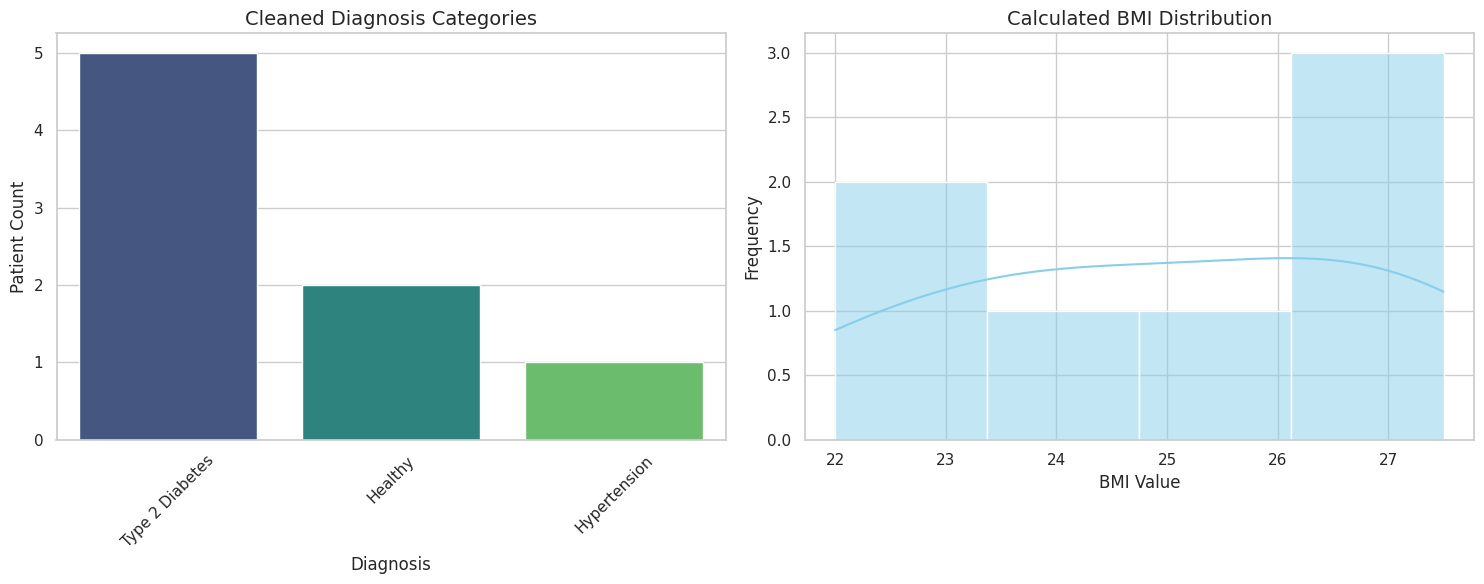

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. Set the visual style
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot 1: Standardized Diagnosis Distribution
# This proves your mapping dictionary successfully grouped the 5 different diabetes names
sns.countplot(data=df_final, x='Diagnosis_Clean', hue='Diagnosis_Clean', palette='viridis', ax=ax1, legend=False)
ax1.set_title('Cleaned Diagnosis Categories', fontsize=14)
ax1.set_xlabel('Diagnosis', fontsize=12)
ax1.set_ylabel('Patient Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# 3. Plot 2: BMI Distribution
# This proves your unit conversion (lbs/kg and cm/m) was mathematically sound
sns.histplot(df_final['BMI'].dropna(), kde=True, color='skyblue', ax=ax2)
ax2.set_title('Calculated BMI Distribution', fontsize=14)
ax2.set_xlabel('BMI Value', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)

plt.tight_layout()

# 4. Save the figure for your GitHub README
plt.savefig('ehr_cleaning_summary.png', dpi=300, bbox_inches='tight')

# 5. Show the plot
plt.show()

# 6. Download the file for your repository
files.download('ehr_cleaning_summary.png')